In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import os

In [2]:
df = pd.read_csv("../data/raw/SBIN.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-01,274.924988,314.000000,315.000000,310.700012,312.450012,6138488
1,2015-01-02,276.019440,315.250000,318.299988,314.350006,314.350006,9935094
2,2015-01-05,273.830566,312.750000,316.799988,312.100006,316.250000,9136716
3,2015-01-06,262.579651,299.899994,311.100006,298.700012,310.000000,15329257
4,2015-01-07,262.798492,300.149994,302.549988,295.149994,300.000000,15046745


In [3]:
print("Shape:", df.shape)

print("\nStart Date:", df["Date"].min())
print("End Date:", df["Date"].max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape: (2878, 7)

Start Date: 2015-01-01 00:00:00
End Date: 2026-08-24 00:00:00

Missing values:
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Data types:
Date         datetime64[ns]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object


In [4]:
# Select Close price as our prediction target
prices = df[["Close"]].values

# 80% training, 20% testing
train_size = int(len(prices) * 0.80)

train_data = prices[:train_size]
test_data = prices[train_size:]

print("Total records:", len(prices))
print("Training records:", len(train_data))
print("Testing records:", len(test_data))

print("\nTrain period:")
print(df["Date"].iloc[0], "to", df["Date"].iloc[train_size - 1])

print("\nTest period:")
print(df["Date"].iloc[train_size], "to", df["Date"].iloc[-1])

Total records: 2878
Training records: 2302
Testing records: 576

Train period:
2015-01-01 00:00:00 to 2024-05-02 00:00:00

Test period:
2024-05-03 00:00:00 to 2026-08-24 00:00:00


In [5]:
# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit ONLY on training data
train_scaled = scaler.fit_transform(train_data)

# Transform test data using the SAME scaler
test_scaled = scaler.transform(test_data)

print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

print("\nFirst 5 scaled training values:")
print(train_scaled[:5])

print("\nFirst 5 scaled testing values:")
print(test_scaled[:5])

Train scaled shape: (2302, 1)
Test scaled shape: (576, 1)

First 5 scaled training values:
[[0.24020907]
 [0.24204947]
 [0.23836867]
 [0.21944934]
 [0.21981742]]

First 5 scaled testing values:
[[1.00206128]
 [0.96724087]
 [0.95855423]
 [0.97165783]
 [0.98490872]]


In [6]:
def create_sequences(data, lookback=60):
    
    X = []
    y = []
    
    for i in range(lookback, len(data)):
        
        # Previous 60 days
        X.append(data[i - lookback:i, 0])
        
        # Next day's price
        y.append(data[i, 0])
    
    return np.array(X), np.array(y)

In [7]:
LOOKBACK = 60

X_train, y_train = create_sequences(
    train_scaled,
    lookback=LOOKBACK
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nExample sequence:")
print(X_train[0][:10])

print("\nTarget:")
print(y_train[0])

X_train shape: (2242, 60)
y_train shape: (2242,)

Example sequence:
[0.24020907 0.24204947 0.23836867 0.21944934 0.21981742 0.22673734
 0.22430802 0.23005007 0.22710542 0.22651651]

Target:
0.17108360545065887


In [8]:
# Combine the last 60 training values with all test values
test_input = np.concatenate(
    (train_scaled[-LOOKBACK:], test_scaled),
    axis=0
)

# Create sequences
X_test, y_test = create_sequences(
    test_input,
    lookback=LOOKBACK
)

print("Test input shape:", test_input.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nExpected test predictions:", len(test_data))

Test input shape: (636, 1)
X_test shape: (576, 60)
y_test shape: (576,)

Expected test predictions: 576


In [9]:
# Reshape data for LSTM
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2242, 60, 1)
y_train shape: (2242,)

X_test shape: (576, 60, 1)
y_test shape: (576,)


In [10]:
# Build LSTM model

model = Sequential([
    
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(LOOKBACK, 1)
    ),
    
    Dropout(0.2),
    
    Dense(25, activation="relu"),
    
    Dense(1)
])

# Compile model
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Display model architecture
model.summary()

C:\Users\Siddhesh Kanchan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,701 (45.71 KB)

 Trainable params: 11,701 (45.71 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    
    epochs=100,
    batch_size=32,
    
    validation_split=0.1,
    
    callbacks=[early_stopping],
    
    verbose=1
)

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0046 - val_loss: 0.0013
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.0533e-04 - val_loss: 6.1266e-04
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.0444e-04 - val_loss: 5.7683e-04
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.8130e-04 - val_loss: 0.0019
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.0550e-04 - val_loss: 0.0011
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.3077e-04 - val_loss: 7.4176e-04
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.8242e-04 - val_loss: 0.0020
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.3029e-04 - val_loss: 4.6172e-04
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.3601e-04 - val_loss: 5.2501e-04
Epoch 11/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.8665e-04 - val_loss: 5.6

In [13]:
# Make predictions on the test data
predictions_scaled = model.predict(X_test)

# Convert scaled predictions back to actual stock prices
predictions = scaler.inverse_transform(predictions_scaled)

# Convert actual test values back to actual prices
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predictions shape:", predictions.shape)
print("Actual prices shape:", actual_prices.shape)

print("\nFirst 5 predictions:")
for actual, predicted in zip(actual_prices[:5], predictions[:5]):
    print(f"Actual: ₹{actual[0]:.2f} | Predicted: ₹{predicted[0]:.2f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Predictions shape: (576, 1)
Actual prices shape: (576, 1)

First 5 predictions:
Actual: ₹831.45 | Predicted: ₹831.30
Actual: ₹807.80 | Predicted: ₹834.59
Actual: ₹801.90 | Predicted: ₹824.14
Actual: ₹810.80 | Predicted: ₹812.68
Actual: ₹819.80 | Predicted: ₹808.52


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(actual_prices, predictions)

rmse = np.sqrt(
    mean_squared_error(actual_prices, predictions)
)

mape = np.mean(
    np.abs(
        (actual_prices - predictions) / actual_prices
    )
) * 100

r2 = r2_score(actual_prices, predictions)

print("===== LSTM FORECAST RESULTS =====")
print(f"MAE: ₹{mae:.2f}")
print(f"RMSE: ₹{rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R² Score: {r2:.4f}")

===== LSTM FORECAST RESULTS =====
MAE: ₹12.03
RMSE: ₹16.44
MAPE: 1.35%
R² Score: 0.9812


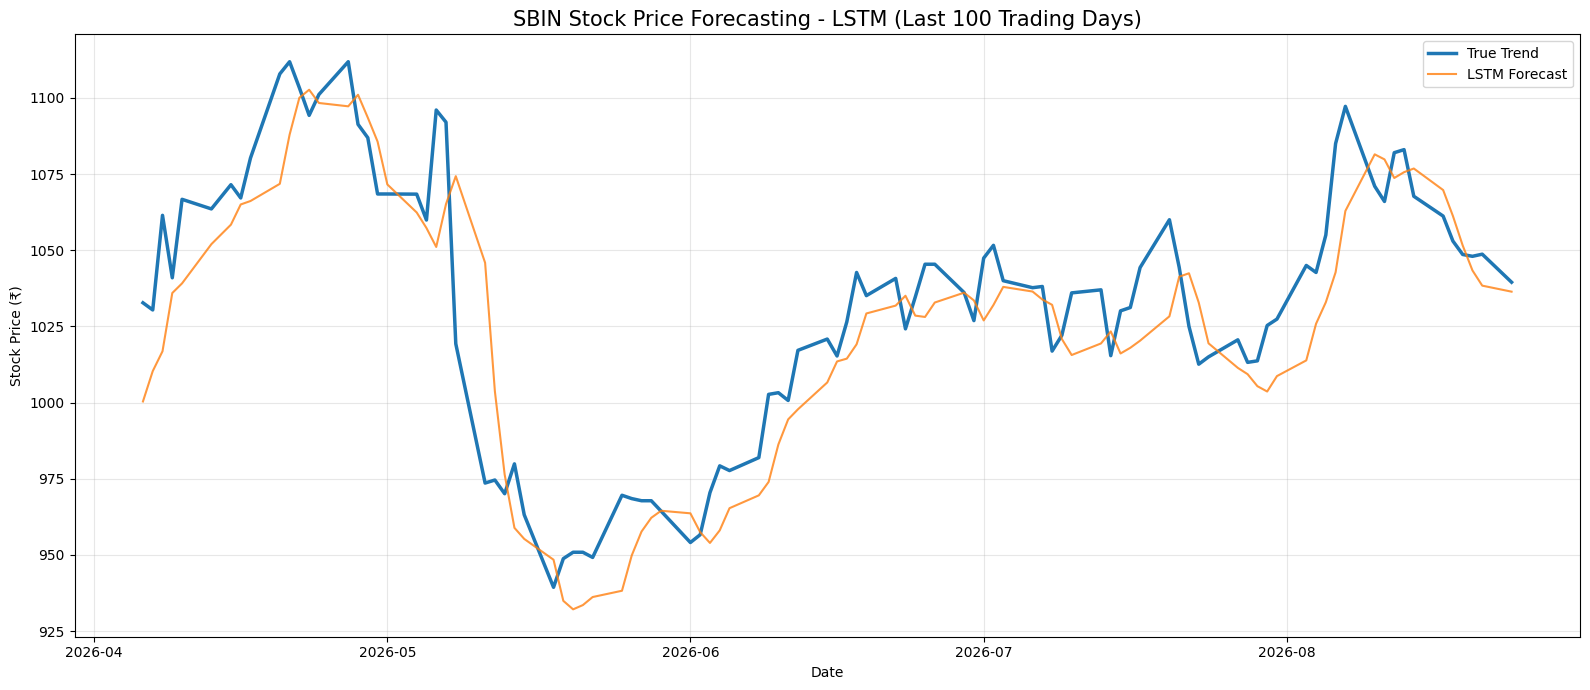

In [19]:
import matplotlib.pyplot as plt

last_n = 100

# Get the dates corresponding to the test set
test_dates = df["Date"].iloc[-len(actual_prices):].reset_index(drop=True)

plt.figure(figsize=(16, 7))

# Actual prices
plt.plot(
    test_dates.iloc[-last_n:],
    actual_prices.flatten()[-last_n:],
    label="True Trend",
    linewidth=2.5
)

# LSTM predictions
plt.plot(
    test_dates.iloc[-last_n:],
    predictions.flatten()[-last_n:],
    label="LSTM Forecast",
    linewidth=1.5,
    alpha=0.8
)

plt.title("SBIN Stock Price Forecasting - LSTM (Last 100 Trading Days)", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Stock Price (₹)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()